# `ANFISpy` tutorial

Here, we are going to give a brief tutorial about the `ANFIS` model usage.

In [1]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import sys
import os

diretorio_atual = os.getcwd()

diretorio_pai = os.path.abspath(os.path.join(diretorio_atual, '..'))

if diretorio_pai not in sys.path:
    sys.path.append(diretorio_pai)


from ANFISpy import ANFIS
from ANFISpy import ProdAND

## Regression

Loading the dataset:

In [2]:
SEED = 10
torch.manual_seed = SEED

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"

df = pd.read_csv(url)
df = df.dropna()

FEATURES = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']
TARGET = ['body_mass_g']

x = df[FEATURES].values
y = df[TARGET].values

Train, test and validation split:

In [3]:
x, index = np.unique(x, axis=0, return_index=True)
y = y[index]

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=SEED)
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.5, random_state=SEED)

x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

x_train_max = x_train.max(dim=0, keepdim=True)[0]
y_train_max = y_train.max(dim=0, keepdim=True)[0]
x_test_max = x_test.max(dim=0, keepdim=True)[0]
y_test_max = y_test.max(dim=0, keepdim=True)[0]
x_val_max = x_val.max(dim=0, keepdim=True)[0]
y_val_max = y_val.max(dim=0, keepdim=True)[0]

x_train /= x_train_max
y_train /= y_train_max
x_test /= x_test_max
y_test /= y_test_max
x_val /= x_val_max
y_val /= y_val_max

Creating the DataLoaders:

In [4]:
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

The model is instantiated with a dictionary, containing information about the `inputs` and `output`. The `inputs` key has the following keys:
- `n_sets`: list with number of fuzzy set of each input variable;
- `uod`: list with tuples/lists representing the universe of discourse of each input variable;
- `var_names`: list with strings for the name of each input variable;
- `mf_names`: list with strings for the name of the fuzzy sets associated to each input variable.

The `output` has similar keys:
- `var_names`: string for the name of the output variable, or a list of strings, if the model is a classifier;
- `n_classes`: if the model is a regressor, set the value to 1.  

This dictionary is then passed to instatiate the model, which is going to use the information in it for plots and model visualization. Here, the `HamacherAND` generalized t-norm is going to be used.

In [5]:
n_vars = 3
mf_names = [['L', 'M', 'H']]

and_op = ProdAND()

variables = {
    'inputs': {
        'n_sets': [3, 3, 3],
        'uod': n_vars * [(0, 1)],
        'var_names': FEATURES,
        'mf_names': n_vars * mf_names,
    },
    'output': {
        'var_names': TARGET[0],
        'n_classes': 1,
    },
}

anfis = ANFIS(
    variables, 
    'gaussian',
    and_operator=and_op
)

Defining the loss function and optimizer:

In [6]:
criterion = nn.MSELoss()
optimizer = optim.Adam(anfis.parameters(), lr=0.001)

Training the model:

In [7]:
epochs = 100
train_losses, val_losses = [], []

for epoch in range(epochs):
    anfis.train()
    train_loss = 0.0
    
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = anfis(x_batch)
        loss = criterion(y_pred, y_batch.flatten())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    anfis.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            y_pred = anfis(x_batch)
            loss = criterion(y_pred, y_batch.flatten())
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    if epoch % 10 == 9:
        print(f'Epoch {epoch+1}/{epochs}: train_loss: {train_loss:.4f} validation_loss {val_loss:.4f}')

TypeError: WeightedSumANFISLayer5.__init__() takes 1 positional argument but 3 were given

Plotting the loss and validation curve:

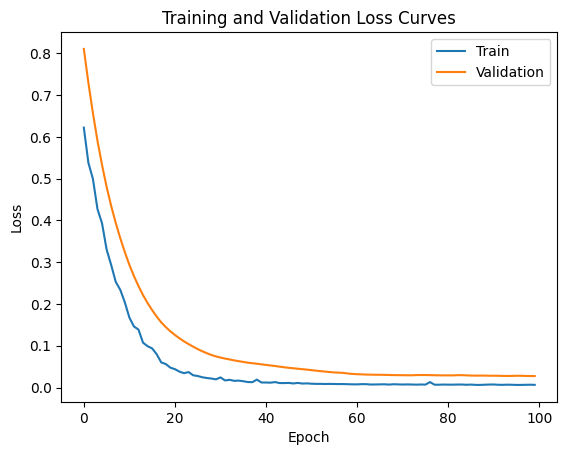

In [ ]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss Curves')
plt.show()

Calculating the RMSE of the model

In [ ]:
anfis.eval()  
test_loss = 0.0

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        y_pred = anfis(x_batch)
        y_pred *= y_test_max.item()
        y_batch *= y_test_max.item()
        mse = torch.mean((y_pred - y_batch.flatten()) ** 2)
        test_loss += mse.item()

rmse = torch.sqrt(torch.tensor(test_loss / len(test_loader)))

print(f"RMSE: {rmse.item():.4f}")

RMSE: 613.0832


Plotting the membership functions of the model:

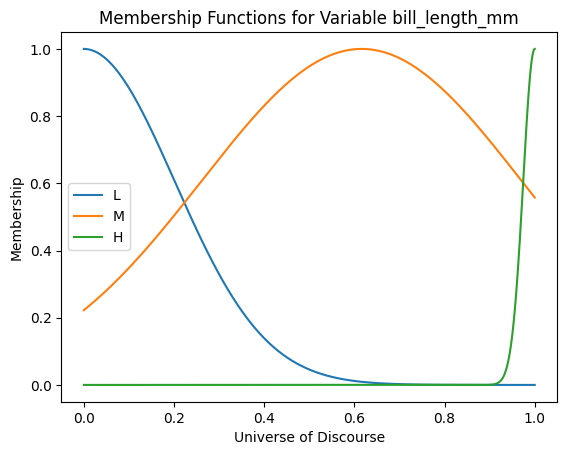

In [ ]:
fig, ax = anfis.plot_var(FEATURES[0])
plt.show()

The following plot depicts the projection of the fuzzy rules into two variables, with the fuzzy sets on the side of the plot.

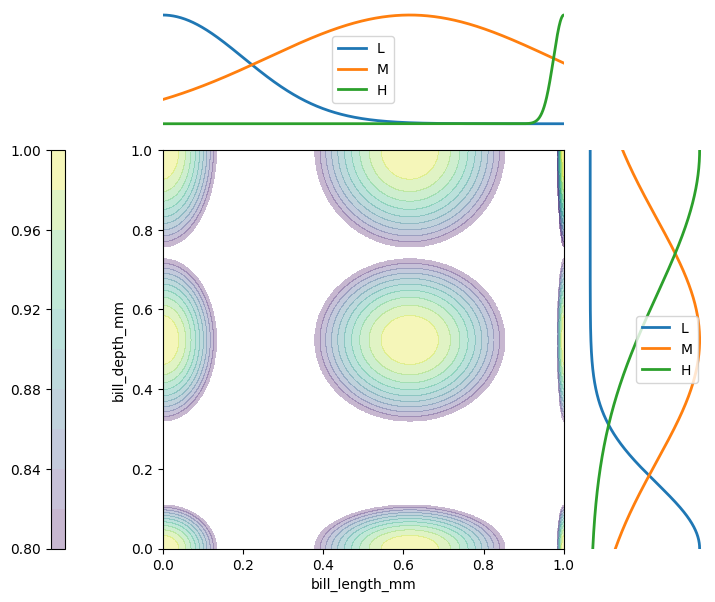

In [ ]:
fig, axes = anfis.plot_rules(FEATURES[:2], thr=0.8)
plt.show()

The rules can be printed via the `.print_rules()` method. It outputs the coefficients of the consequent associated to each antecedent. Printing the rules:

In [ ]:
rules = anfis.print_rules(precision=1)

rules

['Rule 0 (body_mass_g): IF bill_length_mm IS L AND bill_depth_mm IS L AND flipper_length_mm IS L, THEN f0_0 = (0.2 * bill_length_mm) + (0.3 * bill_depth_mm) + (-0.2 * flipper_length_mm) + 0.6',
 'Rule 1 (body_mass_g): IF bill_length_mm IS L AND bill_depth_mm IS L AND flipper_length_mm IS M, THEN f1_0 = (0.4 * bill_length_mm) + (0.2 * bill_depth_mm) + (0.4 * flipper_length_mm) - 0.4',
 'Rule 2 (body_mass_g): IF bill_length_mm IS L AND bill_depth_mm IS L AND flipper_length_mm IS H, THEN f2_0 = (-0.0 * bill_length_mm) + (0.1 * bill_depth_mm) + (0.3 * flipper_length_mm) - 0.2',
 'Rule 3 (body_mass_g): IF bill_length_mm IS L AND bill_depth_mm IS M AND flipper_length_mm IS L, THEN f3_0 = (0.5 * bill_length_mm) + (-0.4 * bill_depth_mm) + (0.0 * flipper_length_mm) + 0.5',
 'Rule 4 (body_mass_g): IF bill_length_mm IS L AND bill_depth_mm IS M AND flipper_length_mm IS M, THEN f4_0 = (-0.1 * bill_length_mm) + (0.3 * bill_depth_mm) + (-0.2 * flipper_length_mm) - 0.4',
 'Rule 5 (body_mass_g): IF bil

Visualizing the mean normalized activation of the rules, with the `.rule_activations()` method:

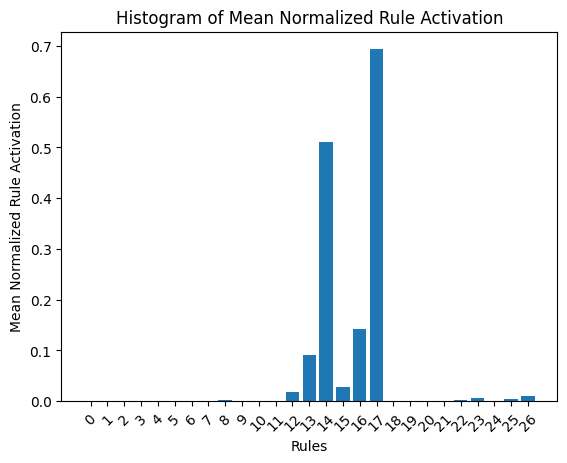

In [ ]:
names = [f'{i}' for i in range(27)]

fig, ax = plt.subplots()

ax.bar(names, anfis.rule_activations(x_test).mean(dim=0).detach())

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45)
ax.set_xlabel('Rules')
ax.set_ylabel('Mean Normalized Rule Activation')
ax.set_title('Histogram of Mean Normalized Rule Activation')

plt.show()

## Classification

Now, we are going to perform a classification problem.

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Loading the dataset:

In [ ]:
SEED = 10
torch.manual_seed = SEED

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"

df = pd.read_csv(url)
df = df.dropna()

FEATURES = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
TARGET = ['species']

print(FEATURES)
print(TARGET)

x = df[FEATURES].values
y = df[TARGET].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y.ravel())

print(x)
print(x.shape)
print(y)
print(y.shape)

Train, test and validation split:

In [ ]:
x, index = np.unique(x, axis=0, return_index=True)
y = y[index]

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=SEED)
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.5, random_state=SEED)

x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

x_train_max = x_train.max(dim=0, keepdim=True)[0]
x_test_max = x_test.max(dim=0, keepdim=True)[0]
x_val_max = x_val.max(dim=0, keepdim=True)[0]

x_train /= x_train_max
x_test /= x_test_max
x_val /= x_val_max

Creating the DataLoaders:

In [ ]:
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Instantiating the model:

In [ ]:
n_vars = len(x[0])
mf_names = [['L', 'M', 'H']]

variables = {
    'inputs': {
        'n_sets': n_vars * [3],
        'uod': n_vars * [(0, 1)],
        'var_names': FEATURES,
        'mf_names': n_vars * mf_names,
    },
    'output': {
        'var_names': label_encoder.classes_,
        'n_classes': len(label_encoder.classes_),
    },
}

anfis = ANFIS(variables, 'gaussian')

Defining the loss and the optimizer:

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(anfis.parameters(), lr=0.001)

Training the model:

In [ ]:
import time
import datetime

inicio = time.time()

epochs = 500
train_losses, val_losses = [], []

for epoch in range(epochs):
    anfis.train()
    train_loss = 0.0
    
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = anfis(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    anfis.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            y_pred = anfis(x_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    if epoch % 10 == 9:
        print(f'Epoch {epoch+1}/{epochs}: train_loss: {train_loss:.4f} validation_loss {val_loss:.4f}')
print(f"Treinamento concluído em: {(time.time() - inicio):.4f} segundos")
tempo_formatado = str(datetime.timedelta(seconds=round((time.time() - inicio))))
print(f"Tempo de execução: {tempo_formatado} (H:MM:SS)")

Epoch 10/500: train_loss: 0.0188 validation_loss 0.3045
Epoch 20/500: train_loss: 0.0189 validation_loss 0.2944
Epoch 30/500: train_loss: 0.0177 validation_loss 0.3352
Epoch 40/500: train_loss: 0.0190 validation_loss 0.3106
Epoch 50/500: train_loss: 0.0168 validation_loss 0.2924
Epoch 60/500: train_loss: 0.0175 validation_loss 0.2960
Epoch 70/500: train_loss: 0.0160 validation_loss 0.2790
Epoch 80/500: train_loss: 0.0152 validation_loss 0.3049
Epoch 90/500: train_loss: 0.0196 validation_loss 0.3137
Epoch 100/500: train_loss: 0.0183 validation_loss 0.3231
Epoch 110/500: train_loss: 0.0163 validation_loss 0.3525
Epoch 120/500: train_loss: 0.0178 validation_loss 0.3225
Epoch 130/500: train_loss: 0.0229 validation_loss 0.3411
Epoch 140/500: train_loss: 0.0130 validation_loss 0.3169
Epoch 150/500: train_loss: 0.0143 validation_loss 0.3253
Epoch 160/500: train_loss: 0.0129 validation_loss 0.3050
Epoch 170/500: train_loss: 0.0309 validation_loss 0.3444
Epoch 180/500: train_loss: 0.0148 valida

Evaluating the performance:

In [ ]:
with torch.no_grad():
    y_pred = anfis(x_test)
    y_pred = torch.argmax(y_pred, dim=1)  
    accuracy = accuracy_score(y_test.numpy(), y_pred.numpy())  
    print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9851


Plotting the confusion matrix:

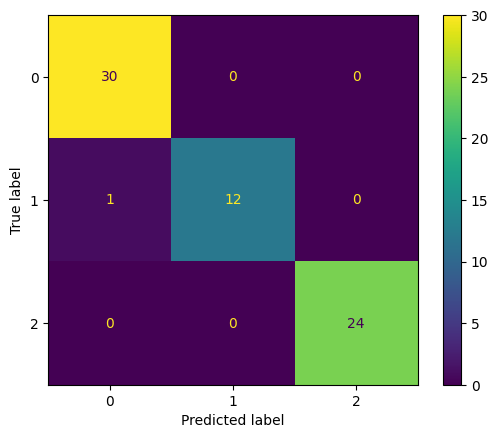

In [ ]:
true_labels = y_test.numpy()
predicted_labels = y_pred.numpy()

cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='viridis')
plt.show()

Printing the rules:

In [ ]:
rules = anfis.print_rules(precision=3)
rules

["Rule 0 (['Adelie' 'Chinstrap' 'Gentoo']): IF bill_length_mm IS L AND bill_depth_mm IS L AND flipper_length_mm IS L AND body_mass_g IS L, THEN f0_0 = (-0.183 * bill_length_mm) + (-0.347 * bill_depth_mm) + (-0.102 * flipper_length_mm) + (-0.062 * body_mass_g) + 0.480",
 "Rule 0 (['Adelie' 'Chinstrap' 'Gentoo']): IF bill_length_mm IS L AND bill_depth_mm IS L AND flipper_length_mm IS L AND body_mass_g IS L, THEN f0_1 = (-0.427 * bill_length_mm) + (-0.337 * bill_depth_mm) + (0.167 * flipper_length_mm) + (0.376 * body_mass_g) + 0.096",
 "Rule 0 (['Adelie' 'Chinstrap' 'Gentoo']): IF bill_length_mm IS L AND bill_depth_mm IS L AND flipper_length_mm IS L AND body_mass_g IS L, THEN f0_2 = (-0.332 * bill_length_mm) + (-0.436 * bill_depth_mm) + (-0.529 * flipper_length_mm) + (-0.272 * body_mass_g) + 0.273",
 "Rule 1 (['Adelie' 'Chinstrap' 'Gentoo']): IF bill_length_mm IS L AND bill_depth_mm IS L AND flipper_length_mm IS L AND body_mass_g IS M, THEN f1_0 = (0.544 * bill_length_mm) + (-0.279 * bill